In [6]:
import cv2
import numpy as np
import glob
import os
import matplotlib.pyplot as plt


# ============================================================
# 1. FUNGSI DETEKSI TANDA TANGAN
# ============================================================

def detect_signature(image_path):

    # Membaca gambar
    img = cv2.imread(image_path)

    if img is None:
        print(f"Gagal membaca: {image_path}")
        return

    # Crop berdasarkan persentase
    # Mencari area kanan atas
    h, w = img.shape[:2]

    y_start = int(h * 0.10)
    y_end   = int(h * 0.35)

    x_start = int(w * 0.65)
    x_end   = int(w * 0.95)

    cropped_img = img[y_start:y_end, x_start:x_end]

    # ========================================================
    # 2. GRAYSCALE
    # ========================================================

    gray = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2GRAY)

    # ========================================================
    # 3. THRESHOLDING
    # ========================================================

    _, global_thresh = cv2.threshold(
        gray,
        127,
        255,
        cv2.THRESH_BINARY_INV
    )

    _, otsu_thresh = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    # ========================================================
    # 4. MORFOLOGI
    # ========================================================

    kernel = np.ones((3, 3), np.uint8)

    opening = cv2.morphologyEx(
        otsu_thresh,
        cv2.MORPH_OPEN,
        kernel
    )

    closing = cv2.morphologyEx(
        opening,
        cv2.MORPH_CLOSE,
        kernel
    )

    # ========================================================
    # 5. KALKULASI PIXEL
    # ========================================================

    foreground_pixels = cv2.countNonZero(closing)

    total_pixels = closing.shape[0] * closing.shape[1]

    pixel_ratio = (
        foreground_pixels / total_pixels
    ) * 100

    # ========================================================
    # 6. STATUS TANDA TANGAN
    # ========================================================

    status = (
        "SIGNATURE PRESENT"
        if pixel_ratio > 1.5
        else "SIGNATURE ABSENT"
    )

    # ========================================================
    # 7. CETAK HASIL
    # ========================================================

    print(f"--- File: {os.path.basename(image_path)} ---")
    print(f"Ukuran Asli Gambar: {w}x{h} piksel")
    print(f"Jumlah Piksel TTD : {foreground_pixels}")
    print(f"Rasio Piksel      : {pixel_ratio:.2f}%")
    print(f"Status            : {status}")
    print("Hasil Crop (Area Kanan Atas):")

    # ========================================================
    # 8. TAMPILKAN GAMBAR
    #    Pengganti cv2_imshow()
    # ========================================================

    plt.figure(figsize=(8, 5))

    # OpenCV membaca gambar dalam format BGR,
    # sedangkan matplotlib menggunakan RGB
    plt.imshow(
        cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)
    )

    plt.axis("off")
    plt.show()

    print("\n")

Memproses 9 gambar...

--- File: 01_HighQuality_Enhanced.jpg ---
Ukuran Asli Gambar: 2481x3506 piksel
Jumlah Piksel TTD : 48376
Rasio Piksel      : 7.41%
Status            : SIGNATURE PRESENT
Hasil Crop (Area Kanan Atas):


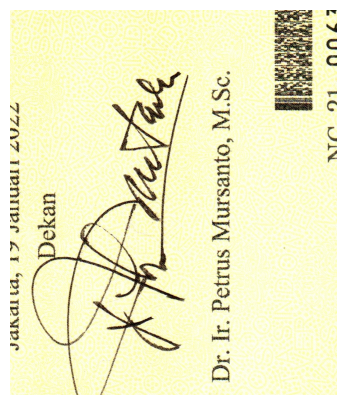



--- File: 02_LowContrast.jpg ---
Ukuran Asli Gambar: 2481x3506 piksel
Jumlah Piksel TTD : 48933
Rasio Piksel      : 7.50%
Status            : SIGNATURE PRESENT
Hasil Crop (Area Kanan Atas):


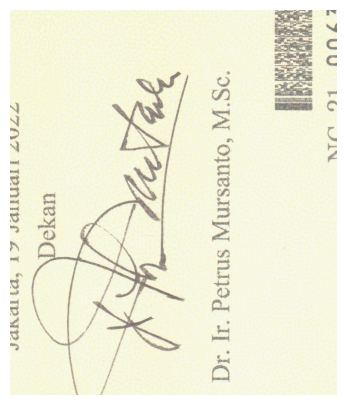



--- File: 03_Blurred.jpg ---
Ukuran Asli Gambar: 2481x3506 piksel
Jumlah Piksel TTD : 76256
Rasio Piksel      : 11.69%
Status            : SIGNATURE PRESENT
Hasil Crop (Area Kanan Atas):


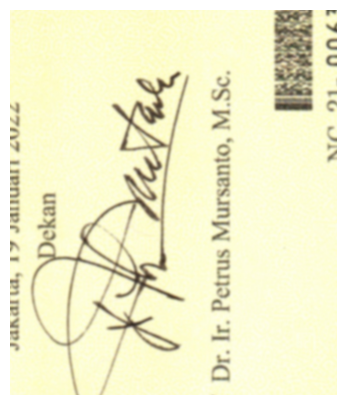



--- File: 04_HighNoise.jpg ---
Ukuran Asli Gambar: 2481x3506 piksel
Jumlah Piksel TTD : 46717
Rasio Piksel      : 7.16%
Status            : SIGNATURE PRESENT
Hasil Crop (Area Kanan Atas):


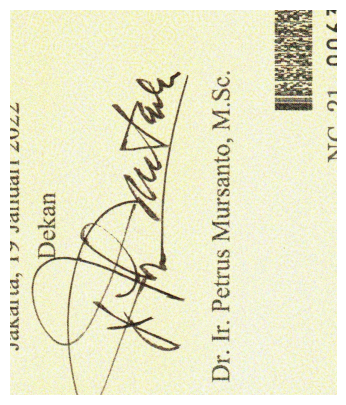



--- File: 05_LowResolution_Upsampled.jpg ---
Ukuran Asli Gambar: 2481x3506 piksel
Jumlah Piksel TTD : 60048
Rasio Piksel      : 9.20%
Status            : SIGNATURE PRESENT
Hasil Crop (Area Kanan Atas):


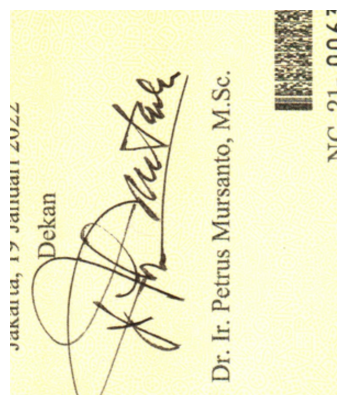



--- File: 06_Faded_Underexposed.jpg ---
Ukuran Asli Gambar: 2481x3506 piksel
Jumlah Piksel TTD : 49777
Rasio Piksel      : 7.63%
Status            : SIGNATURE PRESENT
Hasil Crop (Area Kanan Atas):


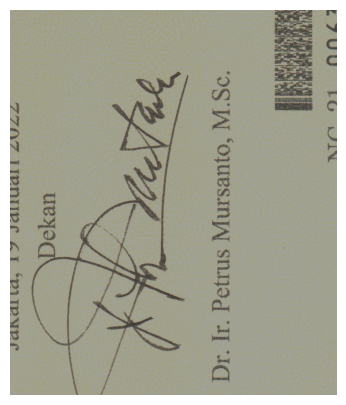



--- File: 07_ColorShift_WarmTint.jpg ---
Ukuran Asli Gambar: 2481x3506 piksel
Jumlah Piksel TTD : 49062
Rasio Piksel      : 7.52%
Status            : SIGNATURE PRESENT
Hasil Crop (Area Kanan Atas):


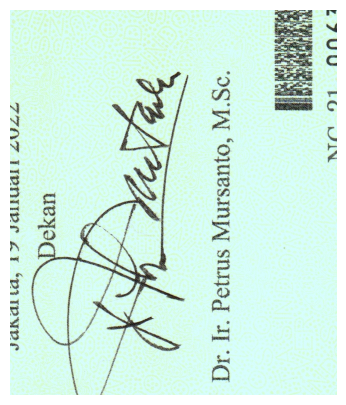



--- File: 08_JPEGCompression_Artifacts.jpg ---
Ukuran Asli Gambar: 2481x3506 piksel
Jumlah Piksel TTD : 50344
Rasio Piksel      : 7.72%
Status            : SIGNATURE PRESENT
Hasil Crop (Area Kanan Atas):


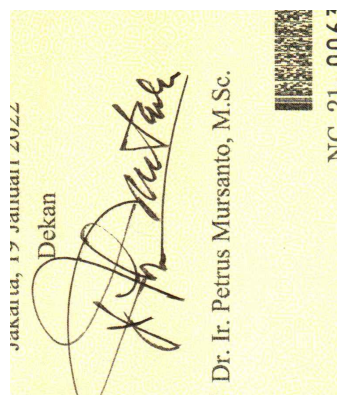



--- File: 09_CombinedDegradation.jpg ---
Ukuran Asli Gambar: 2481x3506 piksel
Jumlah Piksel TTD : 57502
Rasio Piksel      : 8.81%
Status            : SIGNATURE PRESENT
Hasil Crop (Area Kanan Atas):


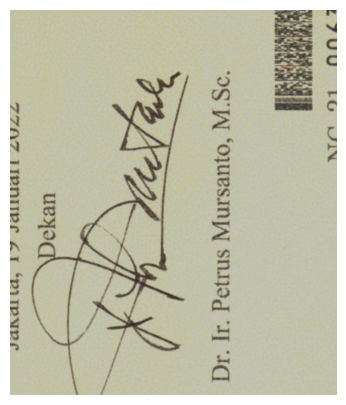

In [7]:
# ============================================================
# 2. EKSEKUSI PROGRAM
# ============================================================

test_images = glob.glob("data/*.*")

if len(test_images) == 0:

    print("WARNING: Folder 'data' kosong atau tidak ditemukan!")
    print("Pastikan folder 'data' berada di folder yang sama")
    print("dengan file Jupyter Notebook kamu.")

else:

    print(f"Memproses {len(test_images)} gambar...\n")

    for img_path in sorted(test_images):
        detect_signature(img_path)

# How to Run Program

## 1. Persiapan

Pastikan Python dan Visual Studio Code sudah terpasang serta ekstensi **Jupyter** pada VS Code sudah tersedia.

## 2. Install Library

Buka terminal VS Code, kemudian jalankan:

```bash
pip install opencv-python numpy matplotlib
```

## 3. Struktur Folder

Pastikan file notebook dan folder gambar memiliki struktur seperti berikut:

```text
project/
│
├── deteksi_ttd.ipynb
│
└── data/
    ├── 01_HighQuality_Enhanced.jpg
    ├── 02_HighQuality_Enhanced.jpg
    ├── 03_HighQuality_Enhanced.jpg
    └── ...
```

Folder `data` digunakan untuk menyimpan gambar yang akan dianalisis.

## 4. Menjalankan Program

Buka file `deteksi_ttd.ipynb` menggunakan Visual Studio Code.

Jalankan cell program secara berurutan, mulai dari cell import library, fungsi `detect_signature()`, hingga cell eksekusi program.

Program akan membaca seluruh gambar yang terdapat di dalam folder `data`.

## 5. Hasil Program

Program akan menampilkan:

* Nama file gambar
* Ukuran asli gambar
* Jumlah piksel tanda tangan
* Rasio piksel tanda tangan
* Status keberadaan tanda tangan
* Hasil crop area kanan atas

Contoh:

```text
--- File: 01_HighQuality_Enhanced.jpg ---
Ukuran Asli Gambar: 2481x3506 piksel
Jumlah Piksel TTD : 48376
Rasio Piksel      : 7.41%
Status            : SIGNATURE PRESENT
```

Hasil crop gambar juga akan ditampilkan langsung pada Jupyter Notebook.